# 01 - Análise exploratória e tratamento dos dados

**Base:** [Telemarketing JYB Dataset](https://www.kaggle.com/datasets/aguado/telemarketing-jyb-dataset) (Kaggle, `aguado/telemarketing-jyb-dataset`, versão 1, atualizada em 02/12/2022).
É uma versão do *Bank Marketing* da UCI (Moro, Cortez e Rita, 2014), com campanhas de telemarketing de um banco português
entre 2008 e 2010. A página do Kaggle indica a licença como "Other (specified in description)"; a base original da UCI é
distribuída sob **CC BY 4.0**.

- `train.csv`: 28.645 contatos com o resultado (`y` = o cliente contratou o depósito a prazo).
- `test.csv`: 12.543 clientes sem resultado. No projeto, eles fazem o papel da base de clientes em produção.

Perguntas desta análise:
1. Qual a qualidade dos dados (nulos, categorias `unknown`, duplicados)?
2. Qual a conversão média e como ela varia por perfil de cliente?
3. A melhor forma de abordar o cliente (canal e dia) muda entre perfis ou ao longo do ano?
4. Quais colunas precisam sair (vazamento, dados sensíveis)?

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import logging
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found")
logging.getLogger("matplotlib").setLevel(logging.WARNING)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": INK_2,
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "text.color": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "axes.titlelocation": "left",
        "figure.dpi": 110,
    }
)

## 1. Carga

O CSV publicado no Kaggle começa com cerca de 1,2 MB de bytes nulos e usa `;` como separador. A função `read_raw_csv`
(a mesma do pipeline) remove esses bytes e padroniza os nomes das colunas.

In [2]:
from src.config import DATA_PATH
from src.data_processing import _resolve_local_path, read_raw_csv

# Usa data/raw/train.csv; se não existir, baixa a base pública do Kaggle.
train_path = _resolve_local_path(DATA_PATH if Path(DATA_PATH).is_absolute() else str(ROOT / DATA_PATH))
raw = read_raw_csv(train_path)
raw["y"] = raw["y"].astype(str).str.lower().isin(["yes", "1"]).astype(int)
print(train_path, raw.shape)

/w/data/raw/train.csv (28645, 21)


In [3]:
raw.head()

,id,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,1,52,technician,married,high.school,no,yes,no,cellular,nov,tue,1,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,0
1,2,33,admin.,single,university.degree,no,yes,no,cellular,nov,thu,1,999,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,0
2,5,54,admin.,single,university.degree,no,yes,no,cellular,may,mon,1,999,0,nonexistent,-1.8,92.893,-46.2,1.264,5099.1,0
3,6,53,housemaid,married,high.school,no,no,yes,cellular,jun,thu,1,999,2,failure,-2.9,92.963,-40.8,1.260,5076.2,1
4,8,42,self-employed,married,university.degree,unknown,yes,no,cellular,aug,tue,2,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,0


In [4]:
raw.dtypes.to_frame("tipo").T

,id,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
tipo,int64,int64,object,object,object,object,object,object,object,object,object,int64,int64,int64,object,float64,float64,float64,float64,float64,int64


## 2. Qualidade dos dados

In [5]:
quality = pd.DataFrame(
    {
        "nulos": raw.isna().sum(),
        "unknown": (raw.astype(str) == "unknown").sum(),
    }
)
quality["unknown_%"] = (100 * quality["unknown"] / len(raw)).round(2)
print("ids duplicados:", raw["id"].duplicated().sum())
quality[quality[["nulos", "unknown"]].sum(axis=1) > 0]

ids duplicados: 0


,nulos,unknown,unknown_%
job,0,242,0.84
marital,0,56,0.20
education,0,1210,4.22
default,0,5952,20.78
housing,0,704,2.46
loan,0,704,2.46


Não há nulos nem ids duplicados. As categorias `unknown` são poucas (a maior é `default`, que será removida por ser
sensível) e foram mantidas como uma categoria própria: removê-las descartaria clientes sem ganho para o modelo.

## 3. Variável alvo

In [6]:
target = raw["y"].value_counts().rename(index={0: "não converteu", 1: "converteu"}).to_frame("clientes")
target["%"] = (100 * target["clientes"] / len(raw)).round(2)
target

,clientes,%
y,,
não converteu,25362,88.54
converteu,3283,11.46


A conversão média é de **11,46%**: a base é desbalanceada, como toda campanha de marketing. Para o bandit isso não
é um problema, porque ele trabalha com a taxa de conversão de cada opção e não com uma classificação.

## 4. Perfil do cliente: idade

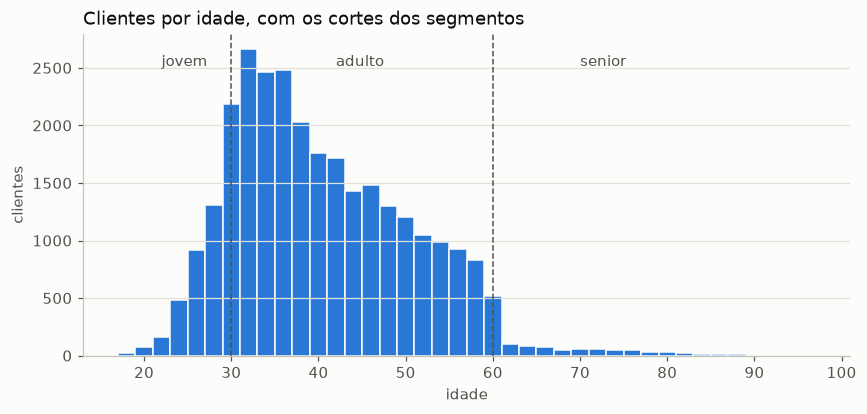

,clientes,conversao_%
segmento,,
jovem,3961,15.93
adulto,23827,9.72
senior,857,39.32


In [7]:
from src.config import assign_segment

raw["segmento"] = raw["age"].map(assign_segment)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(raw["age"], bins=range(17, 99, 2), color="#2a78d6", edgecolor=SURFACE, linewidth=1)
for cut in (30, 60):
    ax.axvline(cut, color=INK_2, linestyle="--", linewidth=1)
ax.text(22, ax.get_ylim()[1] * 0.9, "jovem", color=INK_2)
ax.text(42, ax.get_ylim()[1] * 0.9, "adulto", color=INK_2)
ax.text(70, ax.get_ylim()[1] * 0.9, "senior", color=INK_2)
ax.set_title("Clientes por idade, com os cortes dos segmentos")
ax.set_xlabel("idade")
ax.set_ylabel("clientes")
plt.show()

by_segment = raw.groupby("segmento", observed=True)["y"].agg(clientes="size", conversao="mean")
by_segment["conversao_%"] = (100 * by_segment.pop("conversao")).round(2)
by_segment.loc[["jovem", "adulto", "senior"]]

A maior parte da base está entre 30 e 59 anos, e é justamente o grupo que menos converte. Jovens (< 30) e
seniores (60+) convertem 2 a 4 vezes mais. Por isso a faixa etária entra no contexto da decisão.

## 5. A ação: canal e dia do contato

`contact` (celular ou telefone fixo) e `day_of_week` descrevem **como o banco abordou o cliente**. No projeto, eles
viram os 4 braços do bandit: canal x janela da semana (início = seg a qua, fim = qui e sex).

In [8]:
from src.config import ARM_NAMES, to_arm

raw["braco"] = [to_arm(c, d) for c, d in zip(raw["contact"], raw["day_of_week"], strict=True)]
by_arm = raw.groupby("braco")["y"].agg(contatos="size", conversao="mean").reindex(ARM_NAMES)
by_arm["conversao_%"] = (100 * by_arm.pop("conversao")).round(2)
by_arm

,contatos,conversao_%
braco,,
celular_inicio_semana,10891,14.79
celular_fim_semana,7299,15.23
telefone_inicio_semana,6292,5.07
telefone_fim_semana,4163,5.79


No agregado, os dois braços de celular convertem cerca de 3 vezes mais que o telefone fixo, e
`celular_fim_semana` é o melhor. Uma regra fixa escolheria sempre ele. A questão é se isso vale para todo mundo e
o ano todo.

## 6. Sazonalidade: o mês da campanha

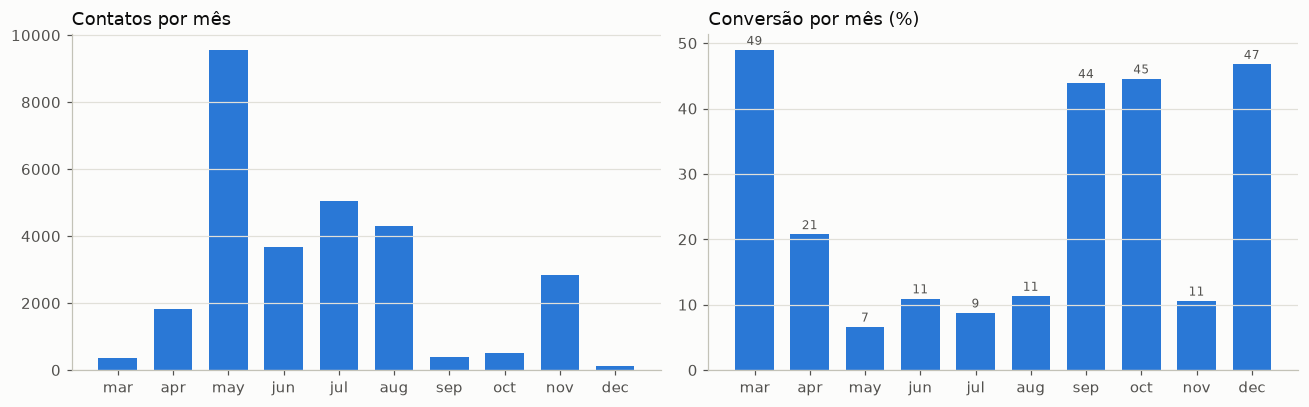

In [9]:
from src.config import MONTHS

months = [m for m in MONTHS if m in set(raw["month"])]
by_month = raw.groupby("month")["y"].agg(contatos="size", conversao="mean").reindex(months)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
x = range(len(months))
ax1.bar(x, by_month["contatos"], color="#2a78d6", width=0.7)
ax1.set_xticks(x, months)
ax1.set_title("Contatos por mês")
ax2.bar(x, 100 * by_month["conversao"], color="#2a78d6", width=0.7)
ax2.set_xticks(x, months)
ax2.set_title("Conversão por mês (%)")
for i, v in enumerate(100 * by_month["conversao"]):
    ax2.text(i, v + 0.8, f"{v:.0f}", ha="center", fontsize=8, color=INK_2)
plt.tight_layout()
plt.show()

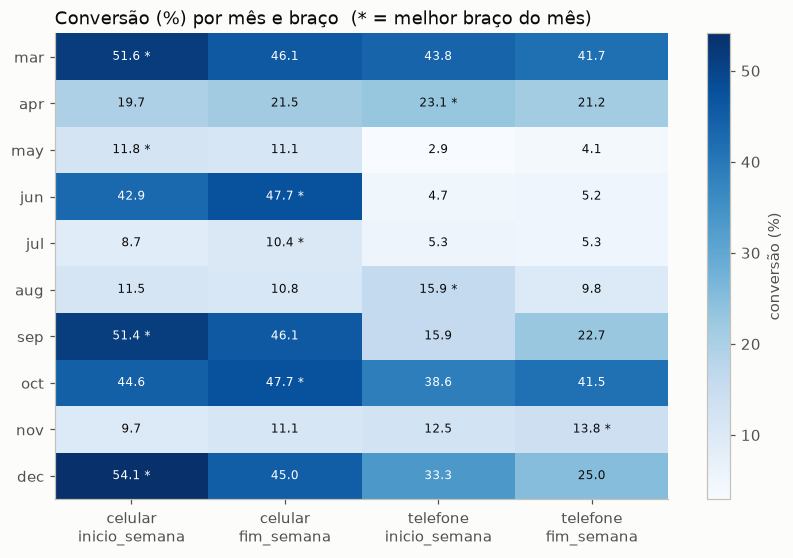

,melhor_braco,contatos_no_mes
month,,
mar,celular_inicio_semana,372
apr,telefone_inicio_semana,1822
may,celular_inicio_semana,9552
jun,celular_fim_semana,3670
jul,celular_fim_semana,5060
aug,telefone_inicio_semana,4287
sep,celular_inicio_semana,399
oct,celular_fim_semana,514
nov,telefone_fim_semana,2845


In [10]:
pivot = {"index": "month", "columns": "braco", "values": "y"}
rate = raw.pivot_table(**pivot, aggfunc="mean").reindex(index=months, columns=ARM_NAMES)
count = raw.pivot_table(**pivot, aggfunc="size").reindex(index=months, columns=ARM_NAMES)
best = rate.idxmax(axis=1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.grid(False)
im = ax.imshow(100 * rate.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(ARM_NAMES)), [a.replace("_", "\n", 1) for a in ARM_NAMES])
ax.set_yticks(range(len(months)), months)
for i, month in enumerate(months):
    for j, arm in enumerate(ARM_NAMES):
        value = 100 * rate.loc[month, arm]
        mark = " *" if arm == best[month] else ""
        ax.text(j, i, f"{value:.1f}{mark}", ha="center", va="center", fontsize=8, color="white" if value > 30 else INK)
ax.set_title("Conversão (%) por mês e braço  (* = melhor braço do mês)")
fig.colorbar(im, ax=ax, label="conversão (%)")
plt.show()

pd.DataFrame({"melhor_braco": best, "contatos_no_mes": count.sum(axis=1).astype(int)})

**Este é o achado central da análise.** A conversão varia muito ao longo do ano: fica entre 7% e 11% de maio a
novembro (exceto abril, com 21%), e entre 44% e 49% em março, setembro, outubro e dezembro, meses com poucos contatos e, mais importante, **o melhor braço muda de mês para mês**: em abril e agosto
o telefone fixo no início da semana ganha, em novembro é o telefone no fim da semana, em setembro e dezembro o celular
no início da semana. Uma regra fixa ("sempre `celular_fim_semana`") erra justamente nesses meses.

O mês da campanha é conhecido no momento da decisão, então pode entrar no contexto sem vazamento. É isso que motiva o
contexto do bandit: **segmento etário x mês da campanha**.

In [11]:
seg_month = raw.pivot_table(index=["month", "segmento"], columns="braco", values="y", aggfunc="mean")
seg_best = seg_month.idxmax(axis=1).unstack("segmento").reindex(index=months)[["jovem", "adulto", "senior"]]
seg_best

segmento,jovem,adulto,senior
month,,,
mar,telefone_fim_semana,celular_fim_semana,telefone_inicio_semana
apr,telefone_inicio_semana,celular_fim_semana,celular_inicio_semana
may,celular_inicio_semana,celular_inicio_semana,celular_inicio_semana
jun,celular_fim_semana,celular_fim_semana,celular_fim_semana
jul,celular_fim_semana,celular_fim_semana,celular_fim_semana
aug,celular_fim_semana,telefone_inicio_semana,telefone_fim_semana
sep,celular_fim_semana,celular_inicio_semana,celular_inicio_semana
oct,celular_fim_semana,celular_fim_semana,celular_inicio_semana
nov,celular_inicio_semana,telefone_fim_semana,celular_inicio_semana


Dentro de um mesmo mês, o melhor braço também pode variar entre os segmentos. Várias células têm poucos contatos
(especialmente seniores), o que torna a estimativa incerta: é o cenário em que a exploração do Thompson Sampling ajuda,
porque ele continua testando onde ainda não tem certeza.

## 7. Outras variáveis do cliente

In [12]:
for col in ["poutcome", "housing", "loan"]:
    t = raw.groupby(col)["y"].agg(clientes="size", conversao="mean")
    t["conversao_%"] = (100 * t.pop("conversao")).round(2)
    display(t)

,clientes,conversao_%
poutcome,,
failure,2870,14.77
nonexistent,24824,9.05
success,951,64.46


,clientes,conversao_%
housing,,
no,12928,11.03
unknown,704,11.36
yes,15013,11.84


,clientes,conversao_%
loan,,
no,23613,11.50
unknown,704,11.36
yes,4328,11.25


Clientes que já converteram numa campanha anterior (`poutcome = success`) convertem 65%. Essas variáveis ficam
disponíveis na Feature Store e são devolvidas pela API junto com a recomendação, mas não entram no contexto do bandit:
com 3 segmentos x 12 meses já são 36 contextos, e cada nova variável multiplica esse número e divide os dados de
cada contexto.

## 8. Colunas removidas

| Motivo | Colunas | Justificativa |
|---|---|---|
| Vazamento temporal | `duration`, `campaign` | `duration` só existe depois da ligação (e já não está neste arquivo). `campaign` conta os contatos da campanha atual, incluindo o último, que é posterior à decisão. |
| Dados sensíveis | `marital`, `default` | Estado civil e inadimplência não devem orientar a oferta (LGPD, risco de discriminação). |
| Não descrevem o cliente | `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | Indicadores macroeconômicos do momento da campanha. O efeito de época já é capturado pelo mês. |
| Viram a ação | `contact`, `day_of_week` | Formam o braço do bandit, não são características do cliente. |

In [13]:
from src.data_processing import LEAKAGE_COLUMNS, MACRO_COLUMNS, SENSITIVE_COLUMNS

print("vazamento:", [c for c in LEAKAGE_COLUMNS if c in raw.columns], "(duration não está no arquivo)")
print("sensíveis:", SENSITIVE_COLUMNS)
print("macro:", MACRO_COLUMNS)

# Sanidade: campaign tem relação inversa com a conversão porque inclui o próprio contato final.
raw.groupby(raw["campaign"].clip(upper=6))["y"].mean().mul(100).round(2).rename("conversao_%").to_frame().T

vazamento: ['campaign'] (duration não está no arquivo)
sensíveis: ['marital', 'default']
macro: ['emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']


campaign,1,2,3,4,5,6
conversao_%,13.19,11.78,10.79,9.64,8.33,5.34


## 9. Base tratada

As mesmas funções do pipeline geram as duas tabelas gravadas no PostgreSQL: `client_features` (Offline Store do Feast,
servida pelo Redis) e `campaign_history` (braço executado, mês e conversão, usada na avaliação).

In [14]:
from datetime import UTC, datetime

from src.data_processing import build_campaign_history, build_client_features, drop_unwanted_columns

clean = drop_unwanted_columns(read_raw_csv(train_path))
features = build_client_features(clean, datetime.now(UTC))
history = build_campaign_history(clean)
print("client_features:", features.shape, "| campaign_history:", history.shape)
display(features.drop(columns=["event_timestamp", "created_timestamp"]).head())
display(history.head())
print(
    "pdays = 999 (nunca contatado) virou -1 em days_since_last_contact:",
    (features["days_since_last_contact"] == -1).mean().round(3),
)

2026-09-27 20:36:23,930 INFO Removendo colunas (vazamento/sensíveis/índice/macro): ['campaign', 'marital', 'default', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']


client_features: (28645, 12) | campaign_history: (28645, 4)


,client_id,age,job,education,housing,loan,previous,days_since_last_contact,poutcome,customer_segment
0,1,52,technician,high.school,yes,no,0,-1,nonexistent,adulto
1,2,33,admin.,university.degree,yes,no,0,-1,nonexistent,adulto
2,5,54,admin.,university.degree,yes,no,0,-1,nonexistent,adulto
3,6,53,housemaid,high.school,no,yes,2,-1,failure,adulto
4,8,42,self-employed,university.degree,yes,no,0,-1,nonexistent,adulto


,client_id,arm,month,converted
0,1,celular_inicio_semana,nov,0
1,2,celular_fim_semana,nov,0
2,5,celular_inicio_semana,may,0
3,6,celular_fim_semana,jun,1
4,8,celular_inicio_semana,aug,0


pdays = 999 (nunca contatado) virou -1 em days_since_last_contact: 0.963


## Resumo

- 28.645 contatos, sem nulos nem duplicados; conversão média de 11,46%.
- Jovens e seniores convertem bem mais que adultos.
- Celular converte ~3x mais que telefone fixo no agregado, mas **o melhor canal e dia mudam conforme o mês**.
- Decisão de modelagem: 4 braços (canal x janela da semana) e contexto = segmento etário x mês da campanha.
- Removidas colunas de vazamento (`duration`, `campaign`), sensíveis (`marital`, `default`) e macroeconômicas.